In [4]:
from pathlib import Path
from datetime import datetime
import json

import cv2
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/home/william/Projetos/PI/atividade1")
OUT_Q1 = ROOT / "saidas_questao1"
OUT_Q2 = ROOT / "saidas_questao2"
OUT_Q3 = ROOT / "saidas_questao3"
OUT_Q4 = ROOT / "saidas_questao4"
OUT_Q5 = ROOT / "saidas_questao5"
OUT_Q6 = ROOT / "saidas_questao6"

OUT_Q1.mkdir(parents=True, exist_ok=True)
OUT_Q2.mkdir(parents=True, exist_ok=True)
OUT_Q3.mkdir(parents=True, exist_ok=True)
OUT_Q4.mkdir(parents=True, exist_ok=True)
OUT_Q5.mkdir(parents=True, exist_ok=True)
OUT_Q6.mkdir(parents=True, exist_ok=True)

print(f"Raiz do projeto: {ROOT}")
print(
    f"Saidas criadas: {OUT_Q1.name}, {OUT_Q2.name}, {OUT_Q3.name}, {OUT_Q4.name}, {OUT_Q5.name}, {OUT_Q6.name}"
)

Raiz do projeto: /home/william/Projetos/PI/atividade1
Saidas criadas: saidas_questao1, saidas_questao2, saidas_questao3, saidas_questao4, saidas_questao5, saidas_questao6


## Questao 1 - Esboco a Lapis



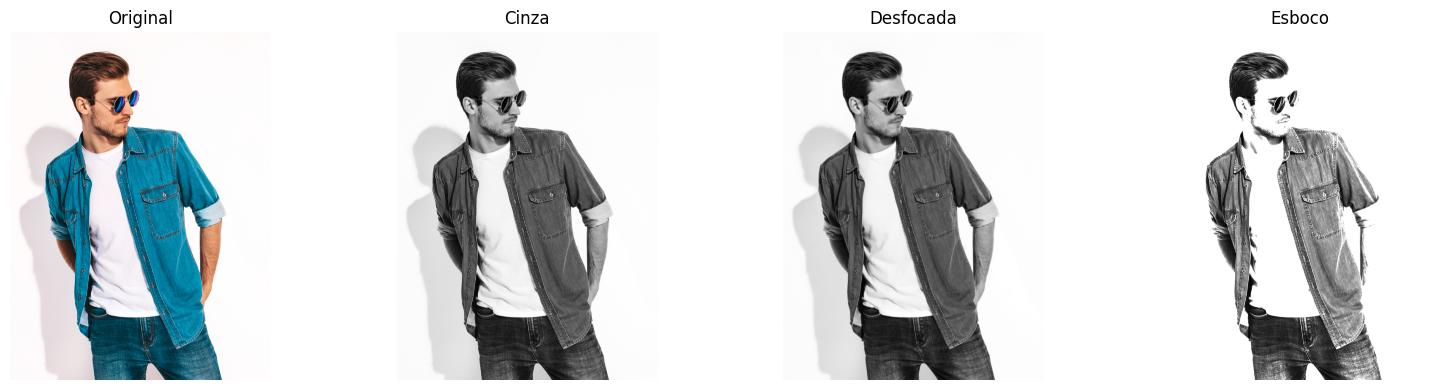

Questao 1 salva em: /home/william/Projetos/PI/atividade1/saidas_questao1
{'cinza': (5555, 4166), 'desfocada': (5555, 4166), 'esboco': (5555, 4166)}


In [5]:
# Questao 1 - implementacao completa
img_q1_path = ROOT / "portrait-handsome-smiling-stylish-young-man-model-wearing-jeans-clothes-sunglasses-fashion-man.jpg"
img_q1 = cv2.imread(str(img_q1_path))
if img_q1 is None:
    raise FileNotFoundError(f"Nao foi possivel carregar a imagem da questao 1: {img_q1_path}")

def converter_para_cinza(img_colorida):
    b = img_colorida[:, :, 0].astype(np.float64)
    g = img_colorida[:, :, 1].astype(np.float64)
    r = img_colorida[:, :, 2].astype(np.float64)
    cinza = 0.299 * r + 0.587 * g + 0.114 * b
    return np.clip(cinza, 0, 255).astype(np.uint8)


def criar_kernel_gaussiano(tamanho, sigma=0):
    if sigma == 0:
        sigma = 0.3 * ((tamanho - 1) * 0.5 - 1) + 0.8
    ax = np.arange(-tamanho // 2 + 1.0, tamanho // 2 + 1.0)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
    return kernel / np.sum(kernel)


def aplicar_gaussiana(img, kernel):
    k_size = kernel.shape[0]
    pad = k_size // 2
    img_pad = np.pad(img.astype(np.float64), pad, mode='edge')
    h, w = img.shape
    resultado = np.zeros_like(img, dtype=np.float64)
    for i in range(h):
        for j in range(w):
            regiao = img_pad[i:i + k_size, j:j + k_size]
            resultado[i, j] = np.sum(regiao * kernel)
    return np.clip(resultado, 0, 255).astype(np.uint8)


def divisor_dodge(cinza, desfocada, escala=255.0):
    cinza_f = cinza.astype(np.float64)
    desfocada_f = desfocada.astype(np.float64)
    denominador = 255.0 - desfocada_f
    denominador = np.where(denominador == 0, 1e-10, denominador)
    esboco = (cinza_f / denominador) * escala
    return np.clip(esboco, 0, 255).astype(np.uint8)

cinza_q1 = converter_para_cinza(img_q1)
kernel_q1 = criar_kernel_gaussiano(21)
desfocada_q1 = aplicar_gaussiana(cinza_q1, kernel_q1)
esboco_q1 = divisor_dodge(cinza_q1, desfocada_q1)

cv2.imwrite(str(OUT_Q1 / "resultado_cinza.jpg"), cinza_q1)
cv2.imwrite(str(OUT_Q1 / "resultado_desfocada.jpg"), desfocada_q1)
cv2.imwrite(str(OUT_Q1 / "resultado_esboco.jpg"), esboco_q1)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img_q1, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")
plt.subplot(1, 4, 2)
plt.imshow(cinza_q1, cmap="gray")
plt.title("Cinza")
plt.axis("off")
plt.subplot(1, 4, 3)
plt.imshow(desfocada_q1, cmap="gray")
plt.title("Desfocada")
plt.axis("off")
plt.subplot(1, 4, 4)
plt.imshow(esboco_q1, cmap="gray")
plt.title("Esboco")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Questao 1 salva em: {OUT_Q1}")
print({"cinza": cinza_q1.shape, "desfocada": desfocada_q1.shape, "esboco": esboco_q1.shape})

## Questao 2 - Correcao Gama



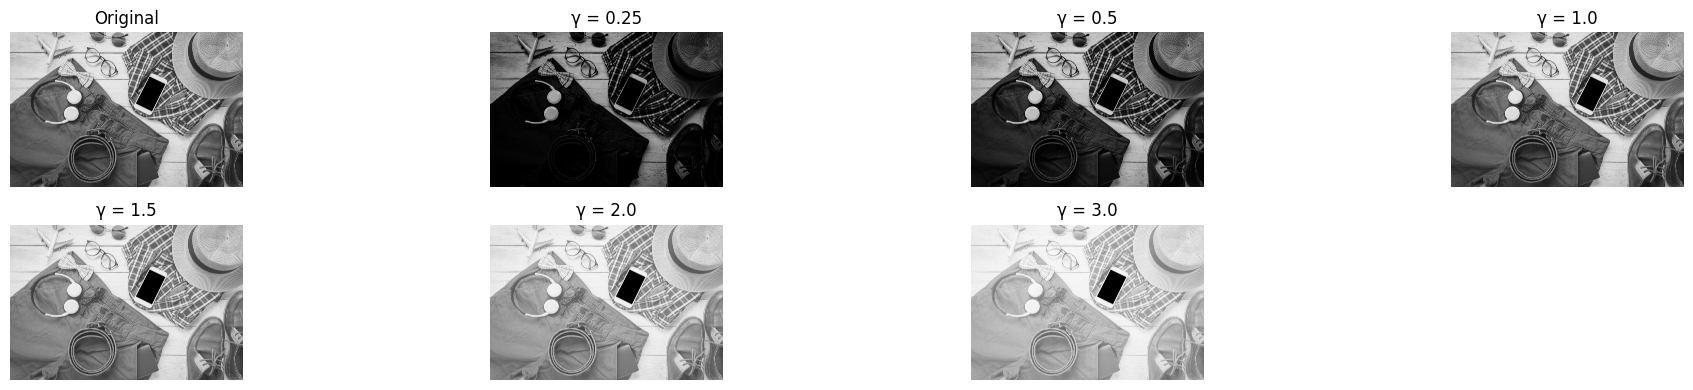

Questao 2 salva em: /home/william/Projetos/PI/atividade1/saidas_questao2
{'0.25': (3168, 4752), '0.5': (3168, 4752), '1.0': (3168, 4752), '1.5': (3168, 4752), '2.0': (3168, 4752), '3.0': (3168, 4752)}


In [6]:
# Questao 2 - implementacao completa
img_q2_path = ROOT / "imagem2.jpg"
img_q2 = cv2.imread(str(img_q2_path), cv2.IMREAD_GRAYSCALE)
if img_q2 is None:
    raise FileNotFoundError(f"Nao foi possivel carregar a imagem da questao 2: {img_q2_path}")


def correcao_gama(img, gamma):
    img_normalizada = img.astype(np.float64) / 255.0
    img_corrigida = np.power(img_normalizada, 1.0 / gamma)
    return np.clip(img_corrigida * 255.0, 0, 255).astype(np.uint8)


gammas_q2 = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
resultados_q2 = {}
for gamma in gammas_q2:
    resultado = correcao_gama(img_q2, gamma)
    resultados_q2[gamma] = resultado
    cv2.imwrite(str(OUT_Q2 / f"imagem2_gama_{gamma}.jpg"), resultado)

plt.figure(figsize=(20, 4))
plt.subplot(2, 4, 1)
plt.imshow(img_q2, cmap="gray")
plt.title("Original")
plt.axis("off")
for i, gamma in enumerate(gammas_q2):
    plt.subplot(2, 4, i + 2)
    plt.imshow(resultados_q2[gamma], cmap="gray")
    plt.title(f"γ = {gamma}")
    plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_Q2 / "comparativo_gama.png", dpi=150)
plt.show()

assert all(resultado.dtype == np.uint8 for resultado in resultados_q2.values())
assert all(resultado.shape == img_q2.shape for resultado in resultados_q2.values())

print(f"Questao 2 salva em: {OUT_Q2}")
print({str(gamma): resultados_q2[gamma].shape for gamma in gammas_q2})

## Questao 3 - Media Ponderada em Niveis de Cinza



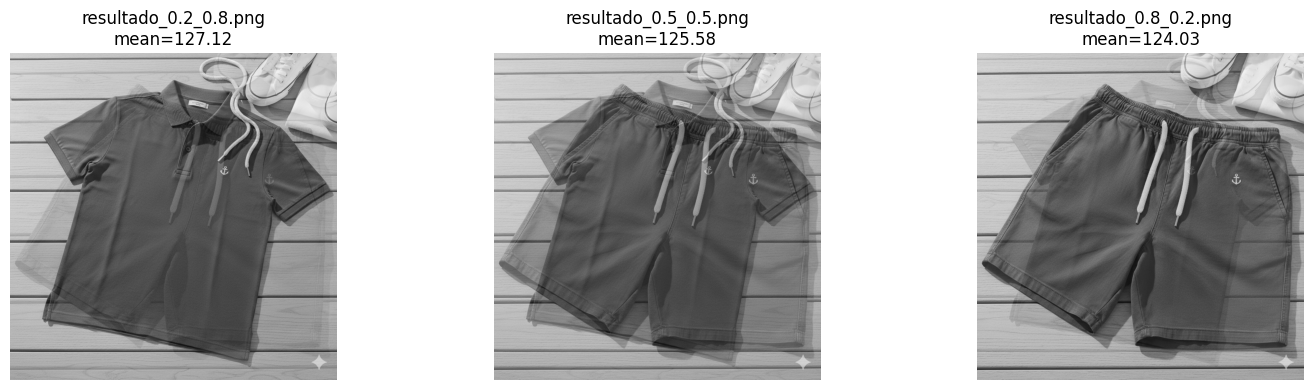

Questao 3 salva em: /home/william/Projetos/PI/atividade1/saidas_questao3
{'resultado_0.2_0.8.png': {'min': 8, 'max': 246, 'mean': 127.12053680419922, 'std': 52.43819645372315}, 'resultado_0.5_0.5.png': {'min': 12, 'max': 244, 'mean': 125.57920551300049, 'std': 50.09034520148637}, 'resultado_0.8_0.2.png': {'min': 12, 'max': 246, 'mean': 124.0263204574585, 'std': 53.973769427373504}}


In [7]:
# Questao 3 - implementacao completa
pasta_q3 = ROOT.parent / "imagens questao 3"
img_q3_1_path = pasta_q3 / "bermuda2.png"
img_q3_2_path = pasta_q3 / "blusa2.png"
img_q3_1 = cv2.imread(str(img_q3_1_path))
img_q3_2 = cv2.imread(str(img_q3_2_path))

if img_q3_1 is None or img_q3_2 is None:
    raise FileNotFoundError("Nao foi possivel carregar uma ou ambas as imagens da questao 3")
if img_q3_1.shape[:2] != img_q3_2.shape[:2]:
    raise ValueError(f"As imagens da questao 3 precisam ter o mesmo tamanho. Recebido: {img_q3_1.shape[:2]} e {img_q3_2.shape[:2]}")


def transformacao_cinza(img):
    if img.ndim == 2:
        return img.astype(np.float32)
    b = img[:, :, 0].astype(np.float32)
    g = img[:, :, 1].astype(np.float32)
    r = img[:, :, 2].astype(np.float32)
    return 0.114 * b + 0.587 * g + 0.299 * r


def media_ponderada(gray1, gray2, w1, w2):
    combinado = w1 * gray1 + w2 * gray2
    return np.clip(combinado, 0, 255).astype(np.uint8)


def resumo_metricas(img):
    return {
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
    }


gray_q3_1 = transformacao_cinza(img_q3_1)
gray_q3_2 = transformacao_cinza(img_q3_2)
comb_q3 = [
    (0.2, 0.8, "resultado_0.2_0.8.png"),
    (0.5, 0.5, "resultado_0.5_0.5.png"),
    (0.8, 0.2, "resultado_0.8_0.2.png"),
]
resultados_q3 = []
metricas_q3 = {}
for w1, w2, nome_saida in comb_q3:
    saida = media_ponderada(gray_q3_1, gray_q3_2, w1, w2)
    resultados_q3.append((w1, w2, nome_saida, saida))
    metricas_q3[nome_saida] = resumo_metricas(saida)
    cv2.imwrite(str(OUT_Q3 / nome_saida), saida)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (w1, w2, nome_saida, saida) in zip(axes, resultados_q3):
    ax.imshow(saida, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{nome_saida}\nmean={metricas_q3[nome_saida]['mean']:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

arquivo_metricas_q3 = OUT_Q3 / "resultado_metricas_execucao.json"
artefato_execucao_q3 = {
    "timestamp": datetime.now().isoformat(),
    "entradas": [str(img_q3_1_path), str(img_q3_2_path)],
    "combinacoes": [{"w1": w1, "w2": w2, "arquivo": nome} for w1, w2, nome in comb_q3],
    "metricas": metricas_q3,
}
with open(arquivo_metricas_q3, "w", encoding="utf-8") as f:
    json.dump(artefato_execucao_q3, f, indent=2, ensure_ascii=False)

assert len(resultados_q3) == 3
assert all(saida.dtype == np.uint8 for _, _, _, saida in resultados_q3)
assert all(saida.shape == gray_q3_1.shape for _, _, _, saida in resultados_q3)

print(f"Questao 3 salva em: {OUT_Q3}")
print(metricas_q3)

## Questao 4 - Transformacoes no Espaco de Intensidades



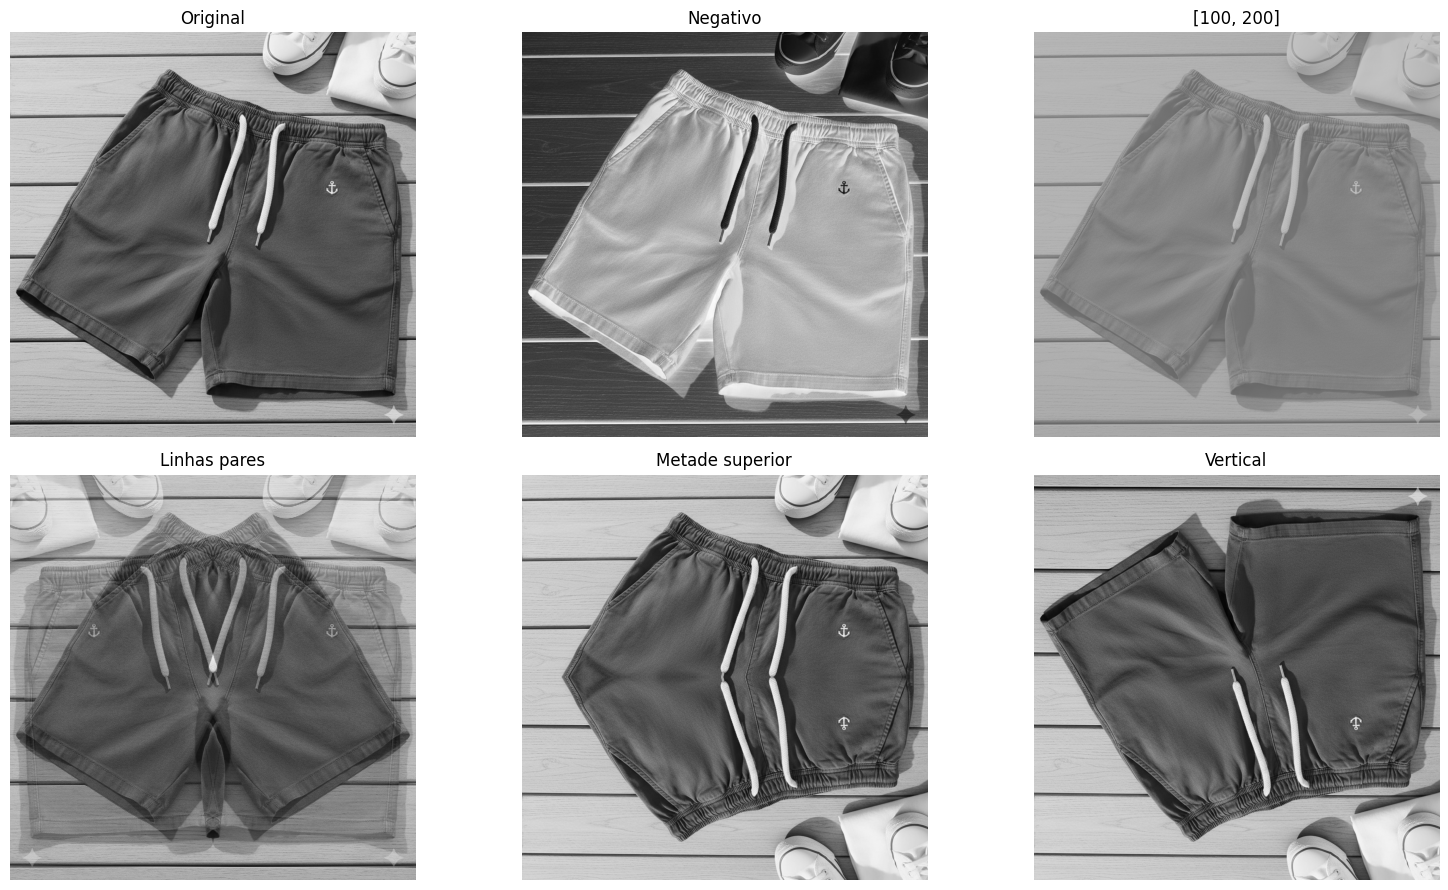

Questao 4 salva em: /home/william/Projetos/PI/atividade1/saidas_questao4
{'01_bermuda_negativo.png': {'min': 0, 'max': 255, 'mean': 131.96627807617188, 'std': 59.48526157908073}, '02_bermuda_remapeado_100_200.png': {'min': 100, 'max': 200, 'mean': 147.7560510635376, 'std': 23.33176979992169}, '03_bermuda_linhas_pares_invertidas.png': {'min': 0, 'max': 255, 'mean': 123.03372192382812, 'std': 59.48526157908073}, '04_bermuda_espelhado_metade_superior.png': {'min': 2, 'max': 255, 'mean': 138.72744178771973, 'std': 63.406180372114726}, '05_bermuda_espelhamento_vertical.png': {'min': 0, 'max': 255, 'mean': 123.03372192382812, 'std': 59.48526157908073}}


In [9]:
# Questao 4 - implementacao completa
pasta_q4 = ROOT / "imagens questao 4 "
img_q4_path = pasta_q4 / "bermuda2.png"
img_q4 = cv2.imread(str(img_q4_path), cv2.IMREAD_GRAYSCALE)
if img_q4 is None:
    raise FileNotFoundError(f"Nao foi possivel carregar a imagem da questao 4: {img_q4_path}")


def negativo(img):
    return (255 - img).astype(np.uint8)


def remapear_100_200(img):
    img_float = img.astype(np.float32)
    remapeado = 100.0 + (img_float * (100.0 / 255.0))
    return np.clip(remapeado, 100, 200).astype(np.uint8)


def inverter_linhas_pares(img):
    resultado = img.copy()
    resultado[0::2, :] = resultado[0::2, ::-1]
    return resultado


def espelhar_metade_superior_na_inferior(img):
    resultado = img.copy()
    altura = resultado.shape[0]
    metade = altura // 2
    metade_superior = resultado[:metade, :].copy()

    if altura % 2 == 0:
        resultado[metade:, :] = metade_superior[::-1]
    else:
        resultado[metade + 1 :, :] = metade_superior[::-1]

    return resultado


def espelhamento_vertical(img):
    return img[::-1, :].copy()


def metricas_basicas(img):
    return {
        "min": int(img.min()),
        "max": int(img.max()),
        "mean": float(np.mean(img)),
        "std": float(np.std(img)),
    }


negativo_q4 = negativo(img_q4)
remapeado_q4 = remapear_100_200(img_q4)
pares_invertidos_q4 = inverter_linhas_pares(img_q4)
espelhado_q4 = espelhar_metade_superior_na_inferior(img_q4)
vertical_q4 = espelhamento_vertical(img_q4)

transformacoes_q4 = [
    ("negativo", "01_bermuda_negativo.png", negativo_q4),
    ("remapeado_100_200", "02_bermuda_remapeado_100_200.png", remapeado_q4),
    ("linhas_pares_invertidas", "03_bermuda_linhas_pares_invertidas.png", pares_invertidos_q4),
    ("espelhado_metade_superior", "04_bermuda_espelhado_metade_superior.png", espelhado_q4),
    ("espelhamento_vertical", "05_bermuda_espelhamento_vertical.png", vertical_q4),
]

metricas_q4 = {}
for nome, arquivo, imagem in transformacoes_q4:
    caminho_saida = OUT_Q4 / arquivo
    ok = cv2.imwrite(str(caminho_saida), imagem)
    if not ok:
        raise IOError(f"Falha ao salvar: {caminho_saida}")
    metricas_q4[arquivo] = metricas_basicas(imagem)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
axes[0].imshow(img_q4, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[1].imshow(negativo_q4, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Negativo")
axes[2].imshow(remapeado_q4, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("[100, 200]")
axes[3].imshow(pares_invertidos_q4, cmap="gray", vmin=0, vmax=255)
axes[3].set_title("Linhas pares")
axes[4].imshow(espelhado_q4, cmap="gray", vmin=0, vmax=255)
axes[4].set_title("Metade superior")
axes[5].imshow(vertical_q4, cmap="gray", vmin=0, vmax=255)
axes[5].set_title("Vertical")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

assert img_q4.ndim == 2, f"Imagem da questao 4 deve ser monocromatica, recebido {img_q4.ndim}D"
assert negativo_q4.shape == img_q4.shape
assert remapeado_q4.shape == img_q4.shape
assert pares_invertidos_q4.shape == img_q4.shape
assert espelhado_q4.shape == img_q4.shape
assert vertical_q4.shape == img_q4.shape
assert remapeado_q4.min() >= 100 and remapeado_q4.max() <= 200
assert all(imagem.dtype == np.uint8 for _, _, imagem in transformacoes_q4)

artefato_q4 = {
    "timestamp": datetime.now().isoformat(),
    "entrada": str(img_q4_path),
    "dimensoes_entrada": list(img_q4.shape),
    "transformacoes": [
        {"nome": nome, "arquivo": arquivo, "metricas": metricas_q4[arquivo]}
        for nome, arquivo, _ in transformacoes_q4
    ],
}
with open(OUT_Q4 / "resultado_metricas_execucao.json", "w", encoding="utf-8") as f:
    json.dump(artefato_q4, f, indent=2, ensure_ascii=False)

print(f"Questao 4 salva em: {OUT_Q4}")
print(metricas_q4)

## Questao 5 - Mosaico 4 x 4



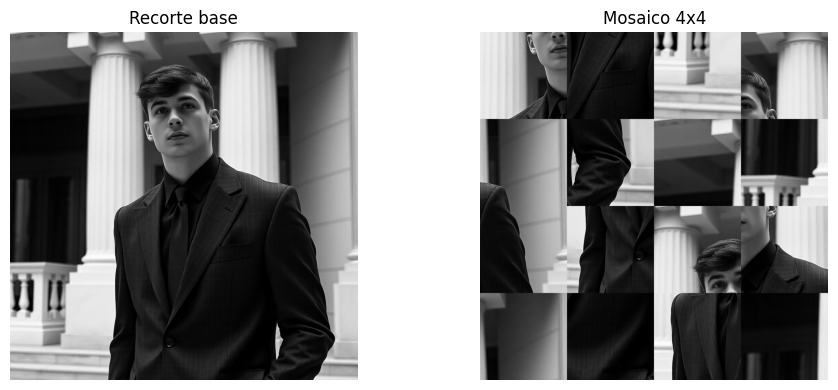

Questao 5 salva em: /home/william/Projetos/PI/atividade1/saidas_questao5
{'recorte_base': {'shape': [1024, 1024], 'min': 0, 'max': 255, 'mean': 90.35577583312988, 'std': 83.65162714306089}, 'mosaico': {'shape': [1024, 1024], 'min': 0, 'max': 255, 'mean': 90.35577583312988, 'std': 83.65162714306089}}


In [10]:
# Questao 5 - implementacao completa
img_q5_path = ROOT / "imagens questao 5" / "image.png"
img_q5 = cv2.imread(str(img_q5_path), cv2.IMREAD_GRAYSCALE)
if img_q5 is None:
    raise FileNotFoundError(f"Nao foi possivel carregar a imagem da questao 5: {img_q5_path}")


def construir_blocos_4x4(img):
    h, w = img.shape
    h4 = (h // 4) * 4
    w4 = (w // 4) * 4
    recorte = img[:h4, :w4]
    bh = h4 // 4
    bw = w4 // 4

    blocos = []
    for i in range(4):
        for j in range(4):
            bloco = recorte[i * bh : (i + 1) * bh, j * bw : (j + 1) * bw].copy()
            blocos.append(bloco)

    return recorte, blocos, bh, bw


def montar_mosaico_por_ordem(blocos, ordem):
    linhas = []
    for linha_ordem in ordem:
        linha_blocos = [blocos[indice - 1] for indice in linha_ordem]
        linhas.append(np.hstack(linha_blocos))
    return np.vstack(linhas)


ordem_q5 = [
    [6, 11, 13, 3],
    [8, 16, 1, 9],
    [12, 14, 2, 7],
    [4, 15, 10, 5],
]

recorte_q5, blocos_q5, bloco_h_q5, bloco_w_q5 = construir_blocos_4x4(img_q5)
mosaico_q5 = montar_mosaico_por_ordem(blocos_q5, ordem_q5)

ok_recorte = cv2.imwrite(str(OUT_Q5 / "01_q5_recorte_base.png"), recorte_q5)
ok_mosaico = cv2.imwrite(str(OUT_Q5 / "02_q5_mosaico_4x4.png"), mosaico_q5)
if not ok_recorte or not ok_mosaico:
    raise IOError("Falha ao salvar resultados da questao 5")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(recorte_q5, cmap="gray", vmin=0, vmax=255)
plt.title("Recorte base")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(mosaico_q5, cmap="gray", vmin=0, vmax=255)
plt.title("Mosaico 4x4")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_Q5 / "03_q5_comparativo.png", dpi=150)
plt.show()

assert recorte_q5.ndim == 2 and mosaico_q5.ndim == 2
assert recorte_q5.dtype == np.uint8 and mosaico_q5.dtype == np.uint8
assert recorte_q5.shape == mosaico_q5.shape
assert bloco_h_q5 > 0 and bloco_w_q5 > 0

metricas_q5 = {
    "recorte_base": {
        "shape": list(recorte_q5.shape),
        "min": int(recorte_q5.min()),
        "max": int(recorte_q5.max()),
        "mean": float(np.mean(recorte_q5)),
        "std": float(np.std(recorte_q5)),
    },
    "mosaico": {
        "shape": list(mosaico_q5.shape),
        "min": int(mosaico_q5.min()),
        "max": int(mosaico_q5.max()),
        "mean": float(np.mean(mosaico_q5)),
        "std": float(np.std(mosaico_q5)),
    },
}

artefato_q5 = {
    "timestamp": datetime.now().isoformat(),
    "entrada": str(img_q5_path),
    "ordem_blocos": ordem_q5,
    "dimensoes_bloco": [int(bloco_h_q5), int(bloco_w_q5)],
    "metricas": metricas_q5,
}

with open(OUT_Q5 / "resultado_metricas_execucao.json", "w", encoding="utf-8") as f:
    json.dump(artefato_q5, f, indent=2, ensure_ascii=False)

print(f"Questao 5 salva em: {OUT_Q5}")
print(metricas_q5)

## Questao 6 - Quantizacao em Diferentes Niveis



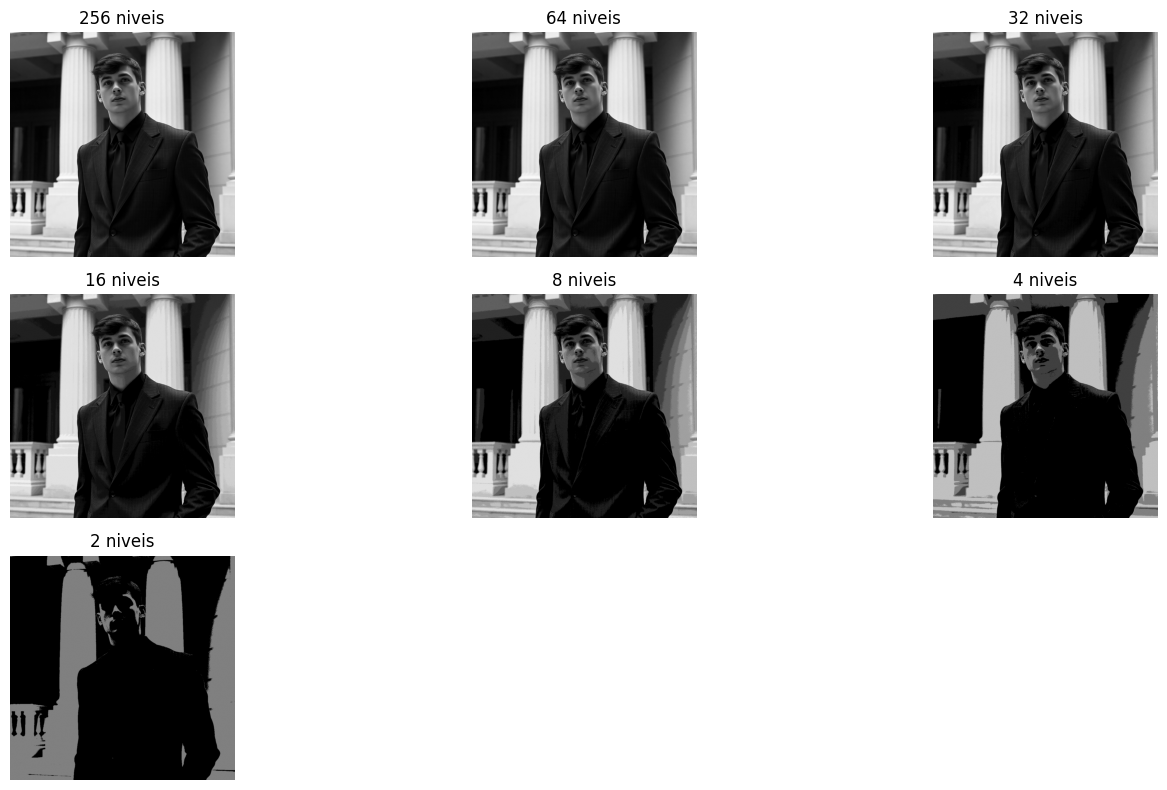

Questao 6 salva em: /home/william/Projetos/PI/atividade1/saidas_questao6
{'256': {'shape': [1024, 1024], 'min': 0, 'max': 255, 'mean': 90.35577583312988, 'std': 83.65162714306089}, '64': {'shape': [1024, 1024], 'min': 0, 'max': 252, 'mean': 88.88463973999023, 'std': 83.63124664172933}, '32': {'shape': [1024, 1024], 'min': 0, 'max': 248, 'mean': 86.94374084472656, 'std': 83.60260198573009}, '16': {'shape': [1024, 1024], 'min': 0, 'max': 240, 'mean': 82.98463439941406, 'std': 83.43580238489476}, '8': {'shape': [1024, 1024], 'min': 0, 'max': 224, 'mean': 76.9033203125, 'std': 83.40347169355736}, '4': {'shape': [1024, 1024], 'min': 0, 'max': 192, 'mean': 64.00030517578125, 'std': 77.59039586931405}, '2': {'shape': [1024, 1024], 'min': 0, 'max': 128, 'mean': 42.4337158203125, 'std': 60.25691152623872}}


In [11]:
# Questao 6 - implementacao completa
img_q6_path = ROOT / "imagens questao 6" / "image.png"
img_q6 = cv2.imread(str(img_q6_path), cv2.IMREAD_GRAYSCALE)
if img_q6 is None:
    raise FileNotFoundError(f"Nao foi possivel carregar a imagem da questao 6: {img_q6_path}")


def quantizar_niveis(img, niveis):
    if niveis == 256:
        return img.copy()

    fator = 256 // niveis
    img_float = img.astype(np.float32)
    quant = np.floor(img_float / fator) * fator
    return np.clip(quant, 0, 255).astype(np.uint8)


niveis_q6 = [256, 64, 32, 16, 8, 4, 2]
resultados_q6 = {}

for nivel in niveis_q6:
    q_img = quantizar_niveis(img_q6, nivel)
    resultados_q6[nivel] = q_img
    ok = cv2.imwrite(str(OUT_Q6 / f"q6_{nivel}_niveis.png"), q_img)
    if not ok:
        raise IOError(f"Falha ao salvar quantizacao de {nivel} niveis")

plt.figure(figsize=(14, 8))
for i, nivel in enumerate(niveis_q6, start=1):
    plt.subplot(3, 3, i)
    plt.imshow(resultados_q6[nivel], cmap="gray", vmin=0, vmax=255)
    plt.title(f"{nivel} niveis")
    plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_Q6 / "q6_comparativo_niveis.png", dpi=150)
plt.show()

for nivel in niveis_q6:
    imagem_q = resultados_q6[nivel]
    assert imagem_q.shape == img_q6.shape
    assert imagem_q.dtype == np.uint8
    assert int(imagem_q.min()) >= 0 and int(imagem_q.max()) <= 255

metricas_q6 = {
    str(nivel): {
        "shape": list(resultados_q6[nivel].shape),
        "min": int(resultados_q6[nivel].min()),
        "max": int(resultados_q6[nivel].max()),
        "mean": float(np.mean(resultados_q6[nivel])),
        "std": float(np.std(resultados_q6[nivel])),
    }
    for nivel in niveis_q6
}

artefato_q6 = {
    "timestamp": datetime.now().isoformat(),
    "entrada": str(img_q6_path),
    "niveis": niveis_q6,
    "metricas": metricas_q6,
}

with open(OUT_Q6 / "resultado_metricas_execucao.json", "w", encoding="utf-8") as f:
    json.dump(artefato_q6, f, indent=2, ensure_ascii=False)

print(f"Questao 6 salva em: {OUT_Q6}")
print(metricas_q6)